In [249]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [250]:
# !pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/matheusmsgomes/.cache/kagglehub/datasets/uciml/default-of-credit-card-clients-dataset/versions/1


In [251]:
import os

# look at all data files
print(os.listdir(path))

['UCI_Credit_Card.csv']


In [252]:
# ebuild full path and load it
file_name = "UCI_Credit_Card.csv"
file_path = os.path.join(path, file_name)

df = pd.read_csv(file_path)

## DATA CLEANING

In [253]:
# initial inspection of data frame
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0 

In [254]:
# check missing values
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

- Pay close attention to default.payment.next.month, PAY_AMT2, and EDUCATION for possible issues
- drop ID as it gives no predictive power (index variable)
- no missing values or non-plausible values in the data
- categorical variables are already in numerical form. no need to format

In [255]:
# drop ID column
df = df.drop('ID', axis=1)

In [256]:
# rename columns for clarity
df = df.rename(columns={
    "default.payment.next.month": "default",
    "PAY_0": "PAY_1"
})

In [257]:
# remove duplicates
df.duplicated().sum()
df = df.drop_duplicates()

In [258]:
# merge 0, 5, and 6 since they are both "unknown" category
# keep "unknown" separate from "other"
df["EDUCATION"] = df["EDUCATION"].replace({0: 5, 5: 5, 6: 5})

# verify
df["EDUCATION"].value_counts()

EDUCATION
2    14019
1    10563
3     4915
5      345
4      123
Name: count, dtype: int64

In [259]:
# MARRIAGE cleanup
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

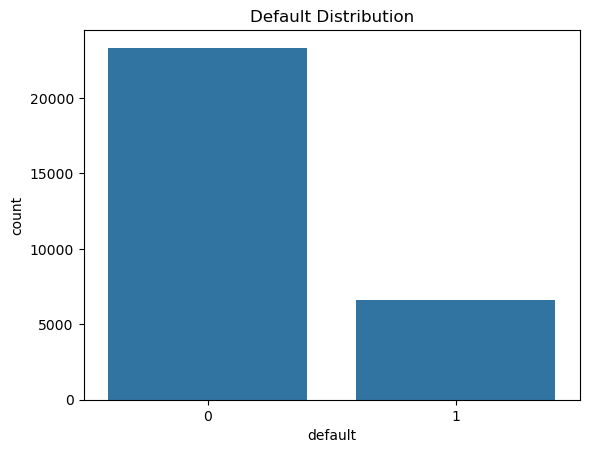

In [260]:
# check target variable distribution
sns.countplot(x="default", data=df)
plt.title("Default Distribution")
plt.show()

- target variable imbalance. address inmediately to avoid bias in the model
- use resampling technique or other

In [261]:
# understand class imbalance
df["default"].value_counts(normalize=True)

default
0    0.778742
1    0.221258
Name: proportion, dtype: float64

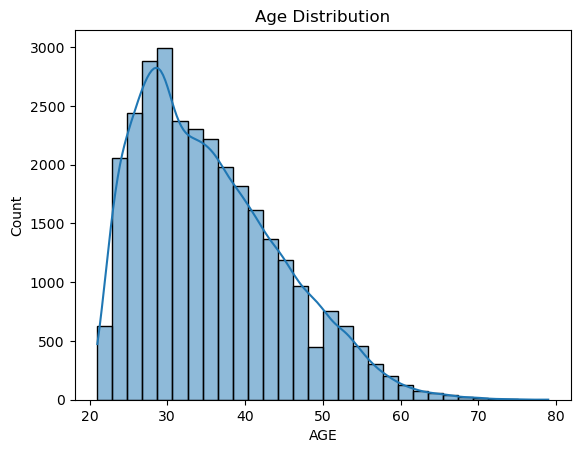

In [262]:
# AGE distribution
sns.histplot(df["AGE"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

- skewness to the right. consider transformation

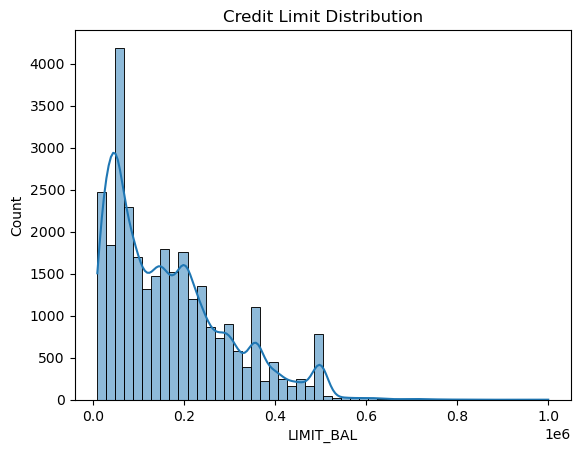

In [263]:
# credit limit distribution
sns.histplot(df["LIMIT_BAL"], bins=50, kde=True)
plt.title("Credit Limit Distribution")
plt.show()

- once again skewness to the right. consdier transformation.
- more unstable than age distribution

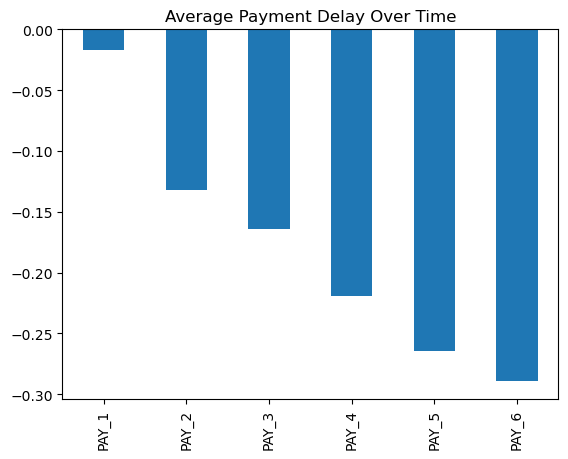

In [264]:
# payment status each month analysis
pay_cols = ["PAY_1","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

df[pay_cols].mean().plot(kind="bar")
plt.title("Average Payment Delay Over Time")
plt.show()

- this graph tells us that loaners tend to struggle more and more as they grow debt continuously each month

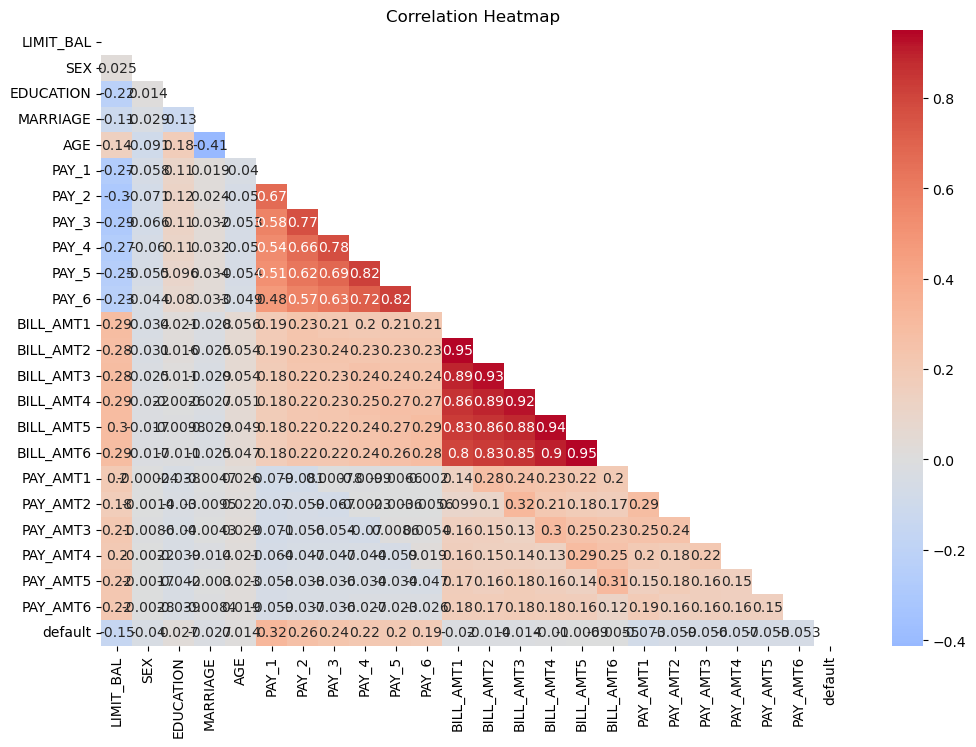

In [265]:
# heatmap correlation
plt.figure(figsize=(12,8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Heatmap")
plt.show()

- be mindful of potential multicollinearity issues.
- high correlation between features makes it impossible to determine the individual importance of variables. interpretability problem


## FEATURE ENGINEERING

In [266]:
bill_cols = ["BILL_AMT1","BILL_AMT2","BILL_AMT3",
            "BILL_AMT4","BILL_AMT5","BILL_AMT6"]

pay_amt_cols = ["PAY_AMT1","PAY_AMT2","PAY_AMT3",
                "PAY_AMT4","PAY_AMT5","PAY_AMT6"]

In [267]:
# total bill amount
df["TOTAL_BILL"] = df[bill_cols].sum(axis=1)

In [268]:
# total payment amount
df["TOTAL_PAY"] = df[pay_amt_cols].sum(axis=1)

In [269]:
# payment ratio (signal)
df["PAY_RATIO"] = df["TOTAL_PAY"] / (df["TOTAL_BILL"] + 1) # +1 to avoid division by 0

In [270]:
# credit utilization (debt to limit percentage)
df["UTILIZATION"] = df["TOTAL_BILL"] / (df["LIMIT_BAL"] + 1)

In [271]:
# log transform for skewed variables
df["LIMIT_BAL_LOG"] = np.log1p(df["LIMIT_BAL"])
df["AGE_LOG"] = np.log1p(df["AGE"])

In [272]:
# df.to_csv(file_path, index=False)

In [273]:
'''
folder_path = "/Users/matheusmsgomes/Documents/Spring 2026/Stats Found AI and DS 2/STA4365_Project"
file_path = os.path.join(folder_path, "cleaned_credit_data_v1.csv")
df.to_csv(file_path, index=False)
print(file_path)
'''

'\nfolder_path = "/Users/matheusmsgomes/Documents/Spring 2026/Stats Found AI and DS 2/STA4365_Project"\nfile_path = os.path.join(folder_path, "cleaned_credit_data_v1.csv")\ndf.to_csv(file_path, index=False)\nprint(file_path)\n'

In [274]:
# print(os.listdir(folder_path))

Interaction Variables to Create

In [275]:
# Repayment Behavior Features

# average delay across 6 months
df["PAY_AVG"] = df[pay_cols].mean(axis=1)

# worst delay ever recorded
df["PAY_MAX"] = df[pay_cols].max(axis=1)

# recent worsening trend
df["PAY_TREND"] = df["PAY_1"] - df["PAY_6"]

These capture:

• consistent lateness\
• severe lateness\
• behavior getting worse recently

In [276]:
# Debt Behavior Features

# average monthly bill
df["AVG_BILL"] = df[bill_cols].mean(axis=1)

# bill volatility
df["BILL_STD"] = df[bill_cols].std(axis=1)

# debt increasing recently
df["BILL_TREND"] = df["BILL_AMT1"] - df["BILL_AMT6"]

In [277]:
# Payment Behavior Features

# average monthly payment
df["AVG_PAY"] = df[pay_amt_cols].mean(axis=1)

# payment consistency
df["PAY_STD"] = df[pay_amt_cols].std(axis=1)

In [278]:
# Best Interaction Terms
df["UTIL_X_PAY1"] = df["UTILIZATION"] * df["PAY_1"]
df["RATIO_X_PAY1"] = df["PAY_RATIO"] * df["PAY_1"]
df["LIMIT_X_UTIL"] = df["LIMIT_BAL_LOG"] * df["UTILIZATION"]
df["AGE_X_PAY1"] = df["AGE_LOG"] * df["PAY_1"]

In [279]:
# Getting CSV with new features/columns
folder_path = "/Users/matheusmsgomes/Documents/Spring 2026/Stats Found AI and DS 2/STA4365_Project"
file_path = os.path.join(folder_path, "cleaned_credit_data_v1.csv")
df.to_csv(file_path, index=False)
print(file_path)

/Users/matheusmsgomes/Documents/Spring 2026/Stats Found AI and DS 2/STA4365_Project/cleaned_credit_data_v1.csv


In [280]:
# Checking which features matter most
corr_target = df.corr(numeric_only=True)["default"].sort_values(ascending=False)
print(corr_target.head(20))
print()
print(corr_target.tail(10))

default         1.000000
PAY_MAX         0.331082
PAY_1           0.324964
AGE_X_PAY1      0.323116
UTIL_X_PAY1     0.316637
PAY_AVG         0.281989
PAY_2           0.263656
PAY_3           0.235230
PAY_4           0.216551
PAY_5           0.204059
PAY_6           0.186740
PAY_TREND       0.129303
UTILIZATION     0.115449
LIMIT_X_UTIL    0.102899
EDUCATION       0.026979
AGE             0.013619
AGE_LOG         0.007301
RATIO_X_PAY1    0.003351
BILL_AMT6      -0.005469
BILL_AMT5      -0.006859
Name: default, dtype: float64

PAY_AMT3        -0.056319
PAY_AMT4        -0.056898
PAY_AMT2        -0.058643
PAY_AMT1        -0.073015
PAY_STD         -0.074123
BILL_STD        -0.079981
AVG_PAY         -0.102488
TOTAL_PAY       -0.102488
LIMIT_BAL       -0.153871
LIMIT_BAL_LOG   -0.173722
Name: default, dtype: float64


The output is telling: 
| Feature     | Correlation with Default |
| ----------- | ------------------------ |
| PAY_MAX     | **0.331**                |
| PAY_1       | 0.325                    |
| AGE_X_PAY1  | 0.323                    |
| UTIL_X_PAY1 | 0.317                    |
| PAY_AVG     | 0.282                    |

Interpretation:

• PAY_MAX = Strongest Predictor

This means:The worst repayment status over 6 months matters more than any single month.

• UTIL_X_PAY1 is Elite Feature

High utilization + recent late payment = strong risk.

• GE_X_PAY1 Strong

Suggests age modifies repayment risk. Younger late payers may behave differently than older ones.

• LIMIT_BAL Negative Correlation

Higher credit limits linked with lower default. Likely stronger credit profiles.

In [281]:
# Top Predictors:
top_features = [
    "PAY_MAX",
    "PAY_1",
    "AGE_X_PAY1",
    "UTIL_X_PAY1",
    "PAY_AVG",
    "PAY_2",
    "PAY_3",
    "PAY_TREND",
    "UTILIZATION",
    "LIMIT_BAL_LOG",
    "AVG_PAY"
]

## Logistic Regression Model

In [282]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


In [283]:
X = df[top_features]
y = df["default"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [284]:
# scale
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [285]:
# L1 - Lasso Logistic
l1_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    max_iter=3000,
    C=1.0
)

l1_model.fit(X_train_s, y_train)
l1_probs = l1_model.predict_proba(X_test_s)[:,1]
l1_auc = roc_auc_score(y_test, l1_probs)

/opt/anaconda3/envs/clean_ds/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/clean_ds/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [286]:
# L2 - Ridge Logistic
l2_model = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    class_weight="balanced",
    max_iter=3000,
    C=1.0
)

l2_model.fit(X_train_s, y_train)
l2_probs = l2_model.predict_proba(X_test_s)[:,1]
l2_auc = roc_auc_score(y_test, l2_probs)

/opt/anaconda3/envs/clean_ds/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [287]:
print("L1 AUC:", round(l1_auc,4))
print("L2 AUC:", round(l2_auc,4))

L1 AUC: 0.7313
L2 AUC: 0.7312


Conclusion from Regularization Models:

• Both models perform almost identically \
• Your features are doing the heavy lifting \
• Regularization type matters less than good feature engineering

Choosing L1 (Lasso)

• same performance \
• simpler model \
• feature selection \
• cleaner interpretation

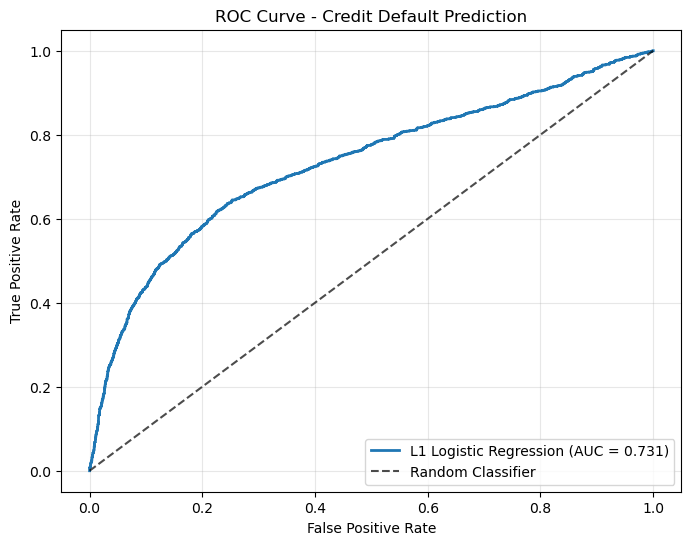

In [288]:
from sklearn.metrics import roc_curve

# Compute ROC points
fpr, tpr, thresholds = roc_curve(y_test, l1_probs)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"L1 Logistic Regression (AUC = {l1_auc:.3f})"
)

# Random baseline
plt.plot([0,1], [0,1], 'k--', alpha=0.7, label="Random Classifier")

# Labels and style
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Default Prediction")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

In [289]:
# Checking which variable L1 selected
coef = pd.Series(l1_model.coef_[0], index=top_features)
coef.sort_values()

AGE_X_PAY1      -0.325673
AVG_PAY         -0.244621
LIMIT_BAL_LOG   -0.197643
UTILIZATION     -0.172721
PAY_2           -0.029244
PAY_3           -0.016343
PAY_AVG          0.000000
PAY_TREND        0.057951
PAY_1            0.307472
PAY_MAX          0.532220
UTIL_X_PAY1      0.580123
dtype: float64

The model judged PAY_AVG redundant

## Confusion Matrix and Precision/Recall Metrics

In [290]:
from sklearn.metrics import classification_report

for t in [0.50, 0.55, 0.60, 0.65, 0.70]:
    pred = (l1_probs >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, pred))


Threshold = 0.5
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      4667
           1       0.44      0.62      0.51      1326

    accuracy                           0.74      5993
   macro avg       0.66      0.70      0.67      5993
weighted avg       0.78      0.74      0.75      5993


Threshold = 0.55
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4667
           1       0.47      0.56      0.51      1326

    accuracy                           0.76      5993
   macro avg       0.67      0.69      0.68      5993
weighted avg       0.78      0.76      0.77      5993


Threshold = 0.6
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      4667
           1       0.53      0.49      0.51      1326

    accuracy                           0.79      5993
   macro avg       0.69      0.68      0.69      5993
weighted avg       0.7

After analyzing different thresholds, I chose threshold = 0.6 because:

Precision crosses 50% \
Recall still close to 50% \
Best balanced tradeoff \
Accuracy improved strongly


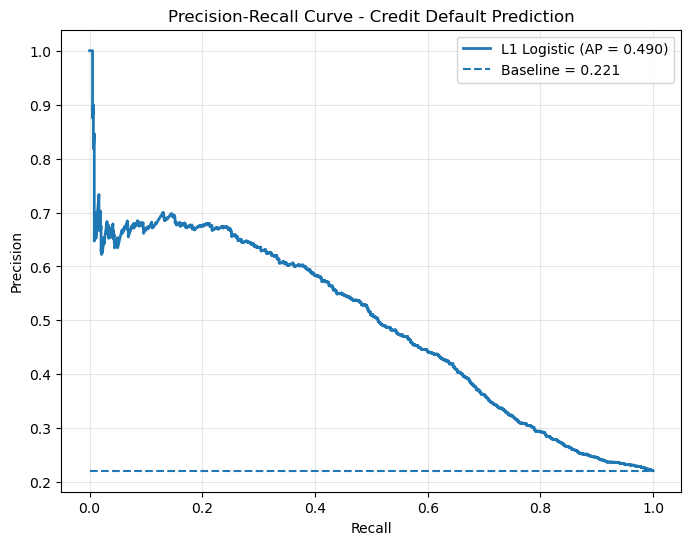

In [291]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, l1_probs)
ap = average_precision_score(y_test, l1_probs)

plt.figure(figsize=(8,6))

plt.plot(recall, precision, linewidth=2,
         label=f"L1 Logistic (AP = {ap:.3f})")

# baseline = prevalence of positive class
baseline = y_test.mean()
plt.hlines(
    baseline,
    xmin=0,
    xmax=1,
    linestyles="--",
    label=f"Baseline = {baseline:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Credit Default Prediction")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Total test observations = 5993
Defaults (support for class 1) = 1326

So Baseline is:
1326 / 5993 = 0.221

So random targeting would give ~22% precision.

The model averages: 49%

In [292]:
# Prediction using thresholds
threshold = 0.60
l1_pred = (l1_probs >= threshold).astype(int)

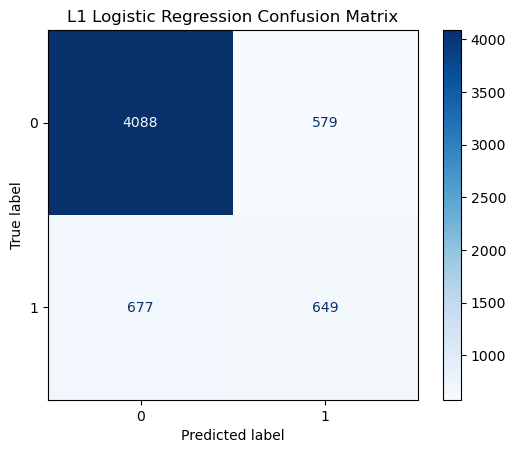

In [293]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, l1_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("L1 Logistic Regression Confusion Matrix")
plt.show()

Confusion Matrix gives us:

TN = 4087 (Borrowers who would not default, correctly classified as safe.)\
FP = 580 (Borrowers predicted to default, but actually would not.)\
FN = 677 (Borrowers predicted safe, but actually defaulted.)\
TP = 649 (Real defaulters correctly identified.)